In [1]:
!ls /kaggle/input


drive-augmented-fundus


In [2]:
import shutil

shutil.copytree("/kaggle/input/drive-augmented-fundus", "/kaggle/working/", dirs_exist_ok=True)


'/kaggle/working/'

In [3]:
aug_img_dir = "/kaggle/working/augmented_training/images"
aug_mask_dir = "/kaggle/working/augmented_training/labels"
custom_test_img_dir = "/kaggle/working/custom_test/images"
custom_test_label_dir = "/kaggle/working/custom_test/labels"


In [4]:
# --- Fix for NumPy 2.0 compatibility issues ---
import numpy as np
if not hasattr(np, 'float'):
    np.float = np.float64
if not hasattr(np, 'int'):
    np.int = np.int64
if not hasattr(np, 'bool'):
    np.bool = np.bool_

/tmp/ipykernel_37/691284739.py:7: FutureWarning: In the future `np.bool` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, 'bool'):


In [6]:

# Core
import os
import shutil
import random
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm

# Augmentation
import albumentations as A

# For visualization
import seaborn as sns
import glob


In [7]:
print("Total augmented images:", len(os.listdir(aug_img_dir)))
print("Total augmented masks:", len(os.listdir(aug_mask_dir)))


Total augmented images: 150
Total augmented masks: 150


In [8]:
print("=== FINAL DATA SUMMARY ===")
print(f"Training images (after augmentation): {len(os.listdir(aug_img_dir))}")
print(f"Test images: {len(os.listdir(custom_test_img_dir))}")

print("\nSample Sizes:")
img_shape = cv2.imread(f"{aug_img_dir}/000.png").shape
mask_shape = cv2.imread(f"{aug_mask_dir}/000.png", cv2.IMREAD_GRAYSCALE).shape
print("Image shape:", img_shape)
print("Mask shape:", mask_shape)

print("\n✅ Dataset ready for Week 2 (Model Development)")


=== FINAL DATA SUMMARY ===
Training images (after augmentation): 150
Test images: 10

Sample Sizes:
Image shape: (512, 512, 3)
Mask shape: (512, 512)

✅ Dataset ready for Week 2 (Model Development)


In [9]:
import os
import glob
import random
from pathlib import Path
from tqdm import tqdm

import cv2            # image I/O and basic ops
import matplotlib.pyplot as plt
import numpy as np    # re-import safe alias after patch

import torch
torch.backends.cudnn.benchmark = True  # optional: can speed up conv ops on fixed-size inputs
torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

# 4) Basic hyperparams / device
IMG_SIZE = (512, 512)
BATCH_SIZE = 4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [10]:
# ----------------------------
# Step 2: Dataset & DataLoader (Fixed)
# ----------------------------

from torch.utils.data import Dataset
from PIL import Image
import torch
import numpy as np
import glob, os

class FundusDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_paths = sorted(glob.glob(os.path.join(image_dir, "*.*")))
        self.mask_paths  = sorted(glob.glob(os.path.join(mask_dir, "*.*")))
        self.transform   = transform

        assert len(self.image_paths) == len(self.mask_paths), \
            f"Image/Mask count mismatch: {len(self.image_paths)} vs {len(self.mask_paths)}"

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Load the image and corresponding mask
        img_path  = self.image_paths[idx]
        mask_path = self.mask_paths[idx]

        # Convert to RGB and grayscale (mask)
        image = Image.open(img_path).convert("RGB")
        mask  = Image.open(mask_path).convert("L")

        # Convert to numpy arrays
        image = np.array(image, dtype=np.float32)
        mask  = np.array(mask,  dtype=np.float32)

        # Normalize image pixels to [0,1]
        if image.max() > 1.0:
            image /= 255.0

        # Convert mask to binary (0 or 1)
        if mask.max() > 1.0:
            mask = mask / 255.0
        mask = (mask > 0.5).astype(np.float32)   # thresholding step

        # Add channel dimension (H, W) → (H, W, 1)
        mask = np.expand_dims(mask, axis=-1)

        # Convert to tensors (CHW format)
        image = torch.from_numpy(image.transpose((2, 0, 1))).float()
        mask  = torch.from_numpy(mask.transpose((2, 0, 1))).float()

        # Apply optional transformations (if any)
        if self.transform:
            image, mask = self.transform(image, mask)

        return image, mask


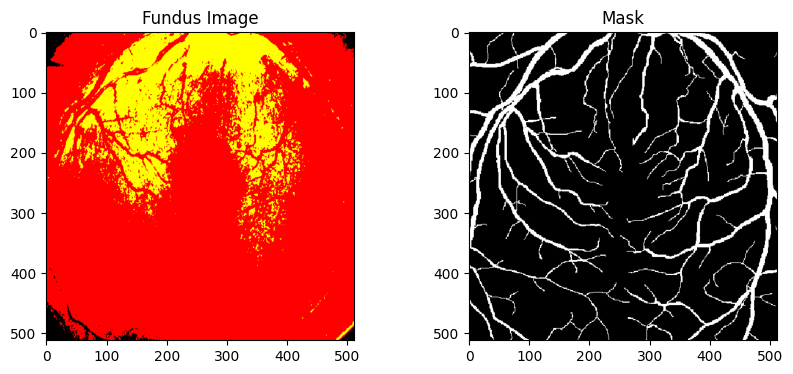

Tensor image stats -> min: 0.0 max: 1.0 mean: 0.38842902


In [11]:
# ----------------------------
# Step 2: Dataset & DataLoader (Fixed)
# ----------------------------

from torch.utils.data import Dataset, DataLoader # Added DataLoader import
from PIL import Image
import torch
import numpy as np
import glob, os

# Define the datasets
train_dataset = FundusDataset(aug_img_dir, aug_mask_dir)
test_dataset  = FundusDataset(custom_test_img_dir,  custom_test_label_dir)

# Wrap into DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
test_loader  = DataLoader(test_dataset,  batch_size=1, shuffle=False, num_workers=2, pin_memory=True)

# Proper visualization from DataLoader tensors
images, masks = next(iter(train_loader))

# Detach tensor and move to CPU if needed
img = images[0].cpu().numpy().transpose(1, 2, 0)
msk = masks[0].cpu().numpy().squeeze()

# Clip and rescale for display
img_disp = np.clip(img, 0, 1)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(img_disp); plt.title("Fundus Image")
plt.subplot(1,2,2); plt.imshow(msk, cmap='gray'); plt.title("Mask")
plt.show()

print("Tensor image stats -> min:", img.min(), "max:", img.max(), "mean:", img.mean())

In [12]:
# ----------------------------
# Step 3.1: Define core building blocks
# ----------------------------
import torch.nn as nn

# A simple helper: 2×(Conv -> BN -> ReLU)
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)


In [13]:
# ----------------------------
# Step 3.2: Define the full U-Net architecture
# ----------------------------
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=[64, 128, 256, 512]):
        super(UNet, self).__init__()
        self.downs = nn.ModuleList()
        self.ups   = nn.ModuleList()
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)

        # Encoder path
        for feature in features:
            self.downs.append(DoubleConv(in_channels, feature))
            in_channels = feature

        # Bottleneck
        self.bottleneck = DoubleConv(features[-1], features[-1]*2)

        # Decoder path
        for feature in reversed(features):
            self.ups.append(
                nn.ConvTranspose2d(feature*2, feature, kernel_size=2, stride=2)
            )
            self.ups.append(DoubleConv(feature*2, feature))

        # Output layer
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        # Encoder
        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        # Bottleneck
        x = self.bottleneck(x)

        # Decoder
        skip_connections = skip_connections[::-1]
        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)  # upsample
            skip_connection = skip_connections[idx//2]

            # Handle potential size mismatch due to pooling
            if x.shape != skip_connection.shape:
                x = nn.functional.interpolate(x, size=skip_connection.shape[2:])

            concat_skip = torch.cat((skip_connection, x), dim=1)
            x = self.ups[idx+1](concat_skip)

        return self.final_conv(x)


In [14]:
# ----------------------------
# Step 3.3: Sanity check
# ----------------------------
model = UNet(in_channels=3, out_channels=1).to(DEVICE)
x = torch.randn((1, 3, 512, 512)).to(DEVICE)
with torch.no_grad():
    preds = model(x)

print("Input shape :", x.shape)
print("Output shape:", preds.shape)


Input shape : torch.Size([1, 3, 512, 512])
Output shape: torch.Size([1, 1, 512, 512])


In [15]:
# ----------------------------
# Step 4.1: Define Dice Loss
# ----------------------------
import torch
import torch.nn as nn
import torch.nn.functional as F

# Dice coefficient for evaluation (expects probabilities in [0,1])
def dice_coef(probs, targets, smooth=1e-6):
    # probs, targets: [B,1,H,W]
    probs = probs.contiguous()
    targets = targets.contiguous()
    intersection = (probs * targets).sum(dim=(2,3))
    denom = probs.sum(dim=(2,3)) + targets.sum(dim=(2,3))
    dice = (2. * intersection + smooth) / (denom + smooth)
    return dice.mean()


In [16]:
class DiceBCELoss(nn.Module):
    def __init__(self, bce_weight=0.2, smooth=1e-5):
        super().__init__()
        self.bce_weight = bce_weight
        self.smooth = smooth
        self.bce = nn.BCELoss()

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)  # convert logits to probabilities
        bce_loss = self.bce(probs, targets)

        probs_flat = probs.view(probs.size(0), -1)
        targets_flat = targets.view(targets.size(0), -1)

        intersection = (probs_flat * targets_flat).sum(-1)
        dice = (2 * intersection + self.smooth) / (
            probs_flat.sum(-1) + targets_flat.sum(-1) + self.smooth
        )
        dice_loss = 1 - dice.mean()

        return self.bce_weight * bce_loss + (1 - self.bce_weight) * dice_loss


In [17]:
# ----------------------------
# Step 4.3: Define optimizer
# ----------------------------
import torch.optim as optim

LEARNING_RATE = 1e-4
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)


In [18]:
# ----------------------------
# Step 4.4: Scheduler
# ----------------------------
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',          # we minimize loss
    factor=0.1,          # reduce LR by 0.1
    patience=5,          # after 5 epochs of no improvement
)


In [19]:
def train_one_epoch(model, dataloader, optimizer, loss_fn, device):
    model.train()
    epoch_loss = 0.0
    dice_sum = 0.0

    for images, masks in dataloader:
        # MOVE DATA TO GPU HERE — THIS WAS THE MISSING STEP
        images = images.to(device, dtype=torch.float32, non_blocking=True)
        masks  = masks.to(device, dtype=torch.float32, non_blocking=True)

        # Ensure mask has shape [B, 1, H, W]
        if masks.ndim == 3:
            masks = masks.unsqueeze(1)

        optimizer.zero_grad(set_to_none=True)

        logits = model(images)  # logits already on GPU because model is on GPU

        # Assertions to *crash instantly* if something is wrong
        assert logits.device == masks.device, "Logits and masks must be on the same device"

        loss = loss_fn(logits, masks)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        probs = torch.sigmoid(logits)

        intersection = (probs * masks).sum(dim=(1,2,3))
        union = probs.sum(dim=(1,2,3)) + masks.sum(dim=(1,2,3))
        dice = (2 * intersection + 1e-7) / (union + 1e-7)

        dice_sum += dice.mean().item()


    return (epoch_loss / len(dataloader)), (dice_sum / len(dataloader))


In [ ]:
@torch.inference_mode()
def validate_one_epoch(model, dataloader, loss_fn, device):
    model.eval()
    val_loss = 0.0
    dice_sum = 0.0  
    steps = len(dataloader)

    for images, masks in dataloader:
        images = images.to(device, dtype=torch.float32, non_blocking=True)
        masks  = masks.to(device, dtype=torch.float32, non_blocking=True)

        # Ensure mask has shape [B, 1, H, W]
        if masks.ndim == 3:
            masks = masks.unsqueeze(1)

        logits = model(images)
        loss = loss_fn(logits, masks)
        val_loss += loss.item()

        probs = torch.sigmoid(logits)

        # Dice per-batch calculation (correct)
        intersection = (probs * masks).sum(dim=(1,2,3))
        union = probs.sum(dim=(1,2,3)) + masks.sum(dim=(1,2,3))
        dice = (2 * intersection + 1e-7) / (union + 1e-7)

        dice_sum += dice.mean().item()

    avg_loss = val_loss / steps
    avg_dice = dice_sum / steps

    return avg_loss, avg_dice


In [21]:
SAVE_PATH = "/kaggle/working/best_unet_model.pth"


In [22]:
def train_model(model, train_loader, val_loader, optimizer, scheduler, loss_fn, num_epochs, device, patience=10):
    best_val_loss = float('inf')
    patience_counter = 0

    history = {'train_loss': [], 'train_dice': [], 'val_loss': [], 'val_dice': []}

    for epoch in range(1, num_epochs + 1):
        
        # ---- TRAIN ----
        train_loss, train_dice = train_one_epoch(
            model, train_loader, optimizer, loss_fn, device
        )

        # ---- VALIDATE ----
        val_loss, val_dice = validate_one_epoch(
            model, val_loader, loss_fn, device
        )

        # ---- LR Scheduler based on VALIDATION LOSS ----
        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['train_dice'].append(train_dice)
        history['val_loss'].append(val_loss)
        history['val_dice'].append(val_dice)

        print(f"Epoch [{epoch}/{num_epochs}] "
              f"Train Loss: {train_loss:.4f} | Train Dice: {train_dice:.4f} || "
              f"Val Loss: {val_loss:.4f} | Val Dice: {val_dice:.4f}")

        # ---- SAVE BEST MODEL BASED ON VALIDATION LOSS ----
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0  # reset
            torch.save({
                'epoch': epoch,
                'model_state': model.state_dict(),
                'optimizer': optimizer.state_dict()
            }, SAVE_PATH)
            print(f"✅ Saved Best Model to {SAVE_PATH} (Val Loss: {best_val_loss:.4f})")
        else:
            patience_counter += 1

        # ---- EARLY STOPPING ----
        if patience_counter >= patience:
            print(f"⛔ Early Stopping Triggered (Val loss did not improve for {patience} epochs)")
            break

    return history


In [23]:
criterion = DiceBCELoss(bce_weight=0.2, smooth=1e-5)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)


In [24]:
img, mask = train_dataset[0]
print(img.shape, img.min().item(), img.max().item())   # expect [3,H,W], 0.0, 1.0
print(mask.shape, mask.unique())                       # expect [1,H,W], tensor([0.,1.])


torch.Size([3, 512, 512]) 0.0 1.0
torch.Size([1, 512, 512]) tensor([0., 1.])


In [25]:
x = torch.randn((1,3,512,512)).to(DEVICE)
out = model(x)
print("logits min/max:", out.min().item(), out.max().item())  # logits, can be >1 or <0
print("output shape:", out.shape)  # [1,1,512,512]


logits min/max: -1.4414830207824707 1.6063270568847656
output shape: torch.Size([1, 1, 512, 512])


In [26]:
!ls -lh /kaggle/working


total 8.0K
drwxr-xr-x 4 root root 4.0K Oct 29 10:50 augmented_training
drwxr-xr-x 4 root root 4.0K Oct 29 10:50 custom_test


In [27]:
# ----------------------------
# Step 6.2: Train the model
# ----------------------------
history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    loss_fn=criterion,
    num_epochs=100,
    device=DEVICE
)

Epoch [1/100] Train Loss: 0.7541 | Train Dice: 0.2134 || Val Loss: 0.7763 | Val Dice: 0.1546
✅ Saved Best Model to /kaggle/working/best_unet_model.pth (Val Loss: 0.7763)
Epoch [2/100] Train Loss: 0.7080 | Train Dice: 0.2427 || Val Loss: 0.5966 | Val Dice: 0.3109
✅ Saved Best Model to /kaggle/working/best_unet_model.pth (Val Loss: 0.5966)
Epoch [3/100] Train Loss: 0.6814 | Train Dice: 0.2666 || Val Loss: 0.4499 | Val Dice: 0.4839
✅ Saved Best Model to /kaggle/working/best_unet_model.pth (Val Loss: 0.4499)
Epoch [4/100] Train Loss: 0.6599 | Train Dice: 0.2869 || Val Loss: 0.4061 | Val Dice: 0.5486
✅ Saved Best Model to /kaggle/working/best_unet_model.pth (Val Loss: 0.4061)
Epoch [5/100] Train Loss: 0.6534 | Train Dice: 0.2915 || Val Loss: 0.5063 | Val Dice: 0.4519
Epoch [6/100] Train Loss: 0.6440 | Train Dice: 0.2999 || Val Loss: 0.3881 | Val Dice: 0.5595
✅ Saved Best Model to /kaggle/working/best_unet_model.pth (Val Loss: 0.3881)
Epoch [7/100] Train Loss: 0.6329 | Train Dice: 0.3111 || 

In [32]:
%matplotlib inline


In [33]:
import matplotlib.pyplot as plt

def plot_history(history):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(14, 5))

    # Loss Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.plot(epochs, history['val_loss'], label='Val Loss')
    plt.title("Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    # Dice Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_dice'], label='Train Dice')
    plt.plot(epochs, history['val_dice'], label='Val Dice')
    plt.title("Dice Score Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Dice Score")
    plt.legend()

    plt.show()


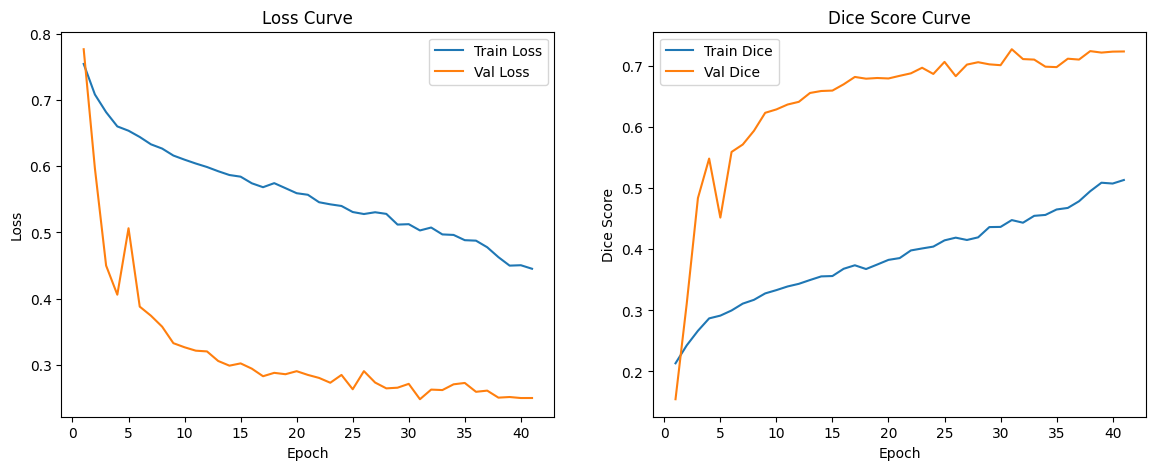

In [34]:
plot_history(history)


In [35]:
import torch
import numpy as np
from sklearn.metrics import precision_score, recall_score, accuracy_score

def evaluate_model_metrics(model, loader, device, threshold=0.5):
    model.eval()
    preds_list, masks_list = [], []

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = torch.sigmoid(model(images))
            preds = (outputs > threshold).float()

            preds_list.append(preds.cpu().numpy().flatten())
            masks_list.append(masks.cpu().numpy().flatten())

    preds_arr = np.concatenate(preds_list)
    masks_arr = np.concatenate(masks_list)

    precision = precision_score(masks_arr, preds_arr)
    recall = recall_score(masks_arr, preds_arr)
    accuracy = accuracy_score(masks_arr, preds_arr)

    return precision, recall, accuracy


In [39]:
# Load Best Model
checkpoint = torch.load(SAVE_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state'])

precision, recall, accuracy = evaluate_model_metrics(model, test_loader, DEVICE, threshold=0.5)
print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, Accuracy: {accuracy:.4f}")


Precision: 0.7073, Recall: 0.8211, Accuracy: 0.9571


In [42]:
for t in [0.4, 0.5, 0.6, 0.7]:
    p, r, a = evaluate_model_metrics(model, test_loader, DEVICE, threshold=t)
    f1 = 2*p*r / (p+r+1e-7)
    print(f"Threshold={t:.1f} | Precision={p:.4f} Recall={r:.4f} Accuracy={a:.4f} Dice(F1)={f1:.4f}")


Threshold=0.4 | Precision=0.6946 Recall=0.8321 Accuracy=0.9559 Dice(F1)=0.7571
Threshold=0.5 | Precision=0.7073 Recall=0.8211 Accuracy=0.9571 Dice(F1)=0.7600
Threshold=0.6 | Precision=0.7197 Recall=0.8098 Accuracy=0.9582 Dice(F1)=0.7621
Threshold=0.7 | Precision=0.7336 Recall=0.7970 Accuracy=0.9593 Dice(F1)=0.7640


In [45]:
import torch

checkpoint = torch.load(SAVE_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state'])
model.to(DEVICE)
model.eval()
print("✅ Model Loaded")


✅ Model Loaded


In [47]:
import torch.nn.functional as F

def predict_mask(model, image_tensor, threshold=0.5):
    model.eval()
    with torch.no_grad():
        logits = model(image_tensor.unsqueeze(0).to(DEVICE))  # (1,1,H,W)
        probs = torch.sigmoid(logits)
        pred = (probs > threshold).float()
    return pred.squeeze().cpu()  # (H,W)


In [48]:
# Example: get one sample from val_loader or a manual path
test_img, test_mask = next(iter(test_loader))  # shape: (B, C, H, W)

test_img = test_img[0]   # take the first image
test_mask = test_mask[0] # first mask

pred_mask = predict_mask(model, test_img, threshold=0.5)


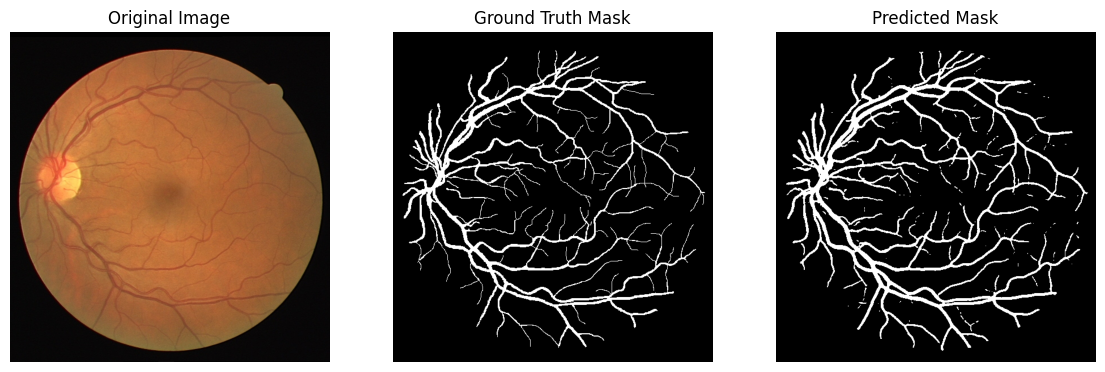

In [51]:
model.eval()
with torch.no_grad():
    test_img, test_mask = next(iter(test_loader))
    test_img = test_img.to(DEVICE)
    
    pred = model(test_img)
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()

# Convert tensors → numpy
img_np = test_img[0].permute(1, 2, 0).cpu().numpy()
mask_np = test_mask[0].cpu().numpy().squeeze()
pred_np = pred[0].cpu().numpy().squeeze()

# Convert image back to original pixel values for display
img_vis = (img_np * 255).astype(np.uint8)

# Plot
plt.figure(figsize=(14,5))
plt.subplot(1,3,1); plt.imshow(img_vis); plt.title("Original Image"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(mask_np, cmap='gray'); plt.title("Ground Truth Mask"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(pred_np, cmap='gray'); plt.title("Predicted Mask"); plt.axis("off")
plt.show()


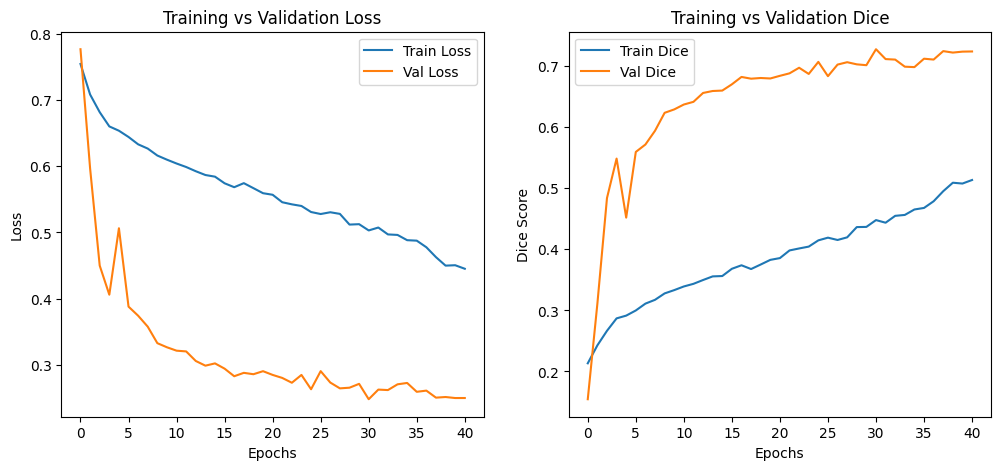

✅ Saved training_curves.png


In [52]:
import matplotlib.pyplot as plt

def plot_training(history):
    plt.figure(figsize=(12,5))

    # Loss Plot
    plt.subplot(1,2,1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()

    # Dice Plot
    plt.subplot(1,2,2)
    plt.plot(history['train_dice'], label='Train Dice')
    plt.plot(history['val_dice'], label='Val Dice')
    plt.xlabel("Epochs")
    plt.ylabel("Dice Score")
    plt.title("Training vs Validation Dice")
    plt.legend()

    plt.savefig("training_curves.png", dpi=300)
    plt.show()

plot_training(history)
print("✅ Saved training_curves.png")


In [56]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision.utils import save_image

SAVE_DIR = "project_output"
os.makedirs(SAVE_DIR, exist_ok=True)

THRESHOLD = 0.5

# Load best model
checkpoint = torch.load(SAVE_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state'])
model.to(DEVICE)
model.eval()

count = 0
for images, masks in test_loader:
    images = images.to(DEVICE)
    masks = masks.to(DEVICE)

    with torch.no_grad():
        preds = torch.sigmoid(model(images))
        preds_bin = (preds > THRESHOLD).float()

    # convert back to original pixel range for visualization
    vis_img = images.cpu().numpy().transpose(0,2,3,1) * 255
    vis_img = vis_img.astype(np.uint8)

    for i in range(images.shape[0]):

        if count >= 2:
            break

        base = f"test_sample_{count+1}"

        # original image (assuming grayscale, else remove [...,0])
        plt.imsave(f"{SAVE_DIR}/{base}_image.png", vis_img[i][...,0], cmap='gray')

        save_image(masks[i], f"{SAVE_DIR}/{base}_true.png")
        save_image(preds_bin[i], f"{SAVE_DIR}/{base}_pred.png")

        overlay = vis_img[i].copy()
        overlay = np.stack([overlay[...,0]]*3, axis=-1)
        overlay[preds_bin[i][0].cpu() == 1] = [255, 0, 0]
        plt.imsave(f"{SAVE_DIR}/{base}_overlay.png", overlay)

        count += 1

    if count >= 2:
        break

print(f"✅ Saved 2 test predictions to {SAVE_DIR}")


✅ Saved 2 test predictions to project_output


In [57]:
import shutil
shutil.copy(SAVE_PATH, f"{SAVE_DIR}/best_unet_model.pth")
print("✅ Model copied to output folder")


✅ Model copied to output folder


In [58]:
import shutil
import os

SAVE_DIR = "project_output"
os.makedirs(SAVE_DIR, exist_ok=True)

if os.path.exists("training_curves.png"):
    shutil.move("training_curves.png", f"{SAVE_DIR}/training_curves.png")
    print("✅ training_curves.png moved into project_output/")
else:
    print("⚠ training_curves.png not found. Did you run the plot cell?")


✅ training_curves.png moved into project_output/


In [62]:
from kaggle_secrets import UserSecretsClient
from IPython.display import FileLink

FileLink('project_output.zip')


/kaggle/working/project_output.zip

In [64]:
from IPython.display import FileLink
FileLink('/kaggle/working/best_unet_model.pth')


/kaggle/working/best_unet_model.pth